# Configuração Inicial e Imports

Esta célula importa todas as bibliotecas necessárias e define os parâmetros globais do projeto:

- **WINDOW**: Tamanho da janela temporal (240 pontos)
- **STRIDE**: Passo entre janelas (1000 pontos)
- **DATASET_PATHS**: Caminhos para os 7 arquivos de dados
- **GLOBAL_MEAN/STD**: Estatísticas globais para normalização dos sensores

Os imports incluem TensorFlow para deep learning, scikit-learn para métricas de avaliação, e bibliotecas padrão para manipulação de dados.

In [ ]:
# Imports
import pandas as pd
import numpy as np
import glob
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

# Parâmetros globais
WINDOW = 240
STRIDE = 1000
SAMPLING_RATE = 1
DATASET_PATHS = [
    '/content/dataset_parte_1.csv', '/content/dataset_parte_2.csv',
    '/content/dataset_parte_3.csv', '/content/dataset_parte_4.csv',
    '/content/dataset_parte_5.csv', '/content/dataset_parte_6.csv',
    '/content/dataset_parte_7.csv'
]

# Estatísticas globais (do enunciado)
GLOBAL_MEAN = 31.9291
GLOBAL_STD = (319.5190 - (-29.3986)) / 1.349  # Approx usando IQR / 1.349


# Funções de Pré-processamento dos Dados

Conjunto de funções responsáveis pelo pré-processamento inicial dos dados:

1. **`load_and_concatenate()`**: Carrega e concatena todos os arquivos CSV dos datasets
2. **`binarize_labels()`**: Converte labels para formato binário (NaN = 0/normal, valor presente = 1/anomalia)
3. **`normalize_sensors()`**: Normaliza os dados dos sensores usando média e desvio padrão globais

A normalização é crucial para estabilizar o treinamento da rede neural LSTM.

In [11]:
def load_and_concatenate(paths):
    df_list = []
    for path in paths:
        df = pd.read_csv(path)
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

def binarize_labels(df):
    df['label'] = df['label'].notna().astype(int)
    return df

def normalize_sensors(df):
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
    df[sensor_cols] = (df[sensor_cols] - GLOBAL_MEAN) / GLOBAL_STD
    return df


# Criação de Janelas Temporais para Cada Sensor

Esta função implementa a estratégia de **janelas deslizantes univariadas**:

- Processa cada sensor individualmente
- Cria janelas de tamanho `WINDOW` com passo `STRIDE`
- Define o label da janela como 1 se houver **pelo menos uma anomalia** na janela
- Cada janela tem formato `(WINDOW, 1)` - sequência temporal univariada
- Resulta em múltiplas sequências temporais para treinamento do modelo LSTM

Esta abordagem permite capturar padrões temporais específicos de cada sensor.

In [12]:
def create_sensor_windows(df, window_size=WINDOW, stride=STRIDE):
    sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
    windows, labels = [], []

    for sensor in sensor_cols:
        series = df[sensor].values
        label_series = df['label'].values

        for i in range(0, len(series) - window_size + 1, stride):
            window = series[i:i + window_size]
            window_label = int(np.any(label_series[i:i + window_size]))
            windows.append(window.reshape(-1, 1))  # shape: (WINDOW, 1)
            labels.append(window_label)

    return np.array(windows), np.array(labels)


# Divisão Temporal dos Dados

Função para dividir os dados mantendo a **ordem cronológica**:

- **70%** para treinamento
- **15%** para validação  
- **15%** para teste

A divisão temporal é essencial para:
- Evitar **data leakage** (vazamento de informações futuras)
- Simular cenário real onde o modelo precisa detectar anomalias em dados futuros
- Garantir avaliação robusta da capacidade de generalização

In [13]:
def temporal_split(X, y):
    total = len(X)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


# Arquitetura do Modelo LSTM

Define a arquitetura da rede neural para detecção de anomalias em séries temporais:

**Componentes principais:**
- **2 camadas LSTM** (64 unidades cada) para capturar dependências temporais
- **BatchNormalization** para estabilizar o treinamento
- **Regularização L2** (0.01) para prevenir overfitting
- **Inicialização HeNormal** para melhor convergência
- **Camada Dense final** com sigmoid para classificação binária

A arquitetura é otimizada para detectar padrões anômalos em sequências temporais.

In [14]:
def create_lstm_shared_model(input_shape=(WINDOW, 1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True, kernel_initializer=HeNormal()),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LSTM(64, kernel_initializer=HeNormal(), kernel_regularizer=l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


# Treinamento e Avaliação do Modelo

Função completa para treinar e avaliar o modelo LSTM:

**Configurações de treinamento:**
- **Binary Focal Cross-entropy Loss** (γ=2.0) para lidar com desbalanceamento de classes
- **Otimizador Adam** para convergência eficiente
- **Early Stopping** (paciência=20) para evitar overfitting
- **ReduceLROnPlateau** (paciência=10) para ajuste automático da taxa de aprendizado

**Avaliação:**
- Threshold de 0.5 para classificação binária
- Relatório detalhado com precision, recall, f1-score

In [15]:
def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test):
    model = create_lstm_shared_model(input_shape=(WINDOW, 1))

    loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

    callbacks = [
        EarlyStopping(patience=20, restore_best_weights=True),
        ReduceLROnPlateau(patience=10)
    ]

    model.fit(X_train, y_train, epochs=100, batch_size=64,
              validation_data=(X_val, y_val), callbacks=callbacks)

    y_pred = (model.predict(X_test) > 0.5).astype(int)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    return model


# Execução do Pipeline Completo

Esta célula executa todo o fluxo de machine learning em sequência:

1. **Carregamento**: Concatena todos os 7 datasets
2. **Pré-processamento**: Binariza labels e normaliza sensores
3. **Criação de janelas**: Gera sequências temporais univariadas
4. **Divisão temporal**: Split em treino/validação/teste
5. **Treinamento**: Executa o modelo LSTM com avaliação

Representa o pipeline end-to-end para detecção de anomalias em sensores industriais.

In [16]:
# Executa pipeline
df = load_and_concatenate(DATASET_PATHS)
df = binarize_labels(df)
df = normalize_sensors(df)

X, y = create_sensor_windows(df)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = temporal_split(X, y)

model = train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test)


/tmp/ipython-input-11-382869801.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 94s 386ms/step - accuracy: 0.8602 - loss: 4.6256 - val_accuracy: 0.9984 - val_loss: 1.0640 - learning_rate: 0.0010
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 138s 369ms/step - accuracy: 0.9980 - loss: 0.7057 - val_accuracy: 0.9984 - val_loss: 0.1472 - learning_rate: 0.0010
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 142s 371ms/step - accuracy: 0.9976 - loss: 0.0994 - val_accuracy: 0.9984 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 147s 394ms/step - accuracy: 0.9982 - loss: 0.0187 - val_accuracy: 0.9984 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 87s 386ms/step - accuracy: 0.9981 - loss: 0.0077 - val_accuracy: 0.9984 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 91s 405ms/step - accuracy: 0.9977 - loss: 0.0064 - val_accuracy: 0.9984 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 144s 413ms/step - ac

# Visualização das Curvas de Loss

Gráfico da evolução do loss durante o treinamento:

- **Training Loss** (azul): Loss no conjunto de treinamento
- **Validation Loss** (laranja): Loss no conjunto de validação

**Análise importante:**
- Convergência das curvas indica bom ajuste do modelo
- Gap entre as curvas mostra se há overfitting
- Tendência decrescente confirma aprendizado efetivo
- Valores finais baixos (≈0.0006) indicam excelente performance

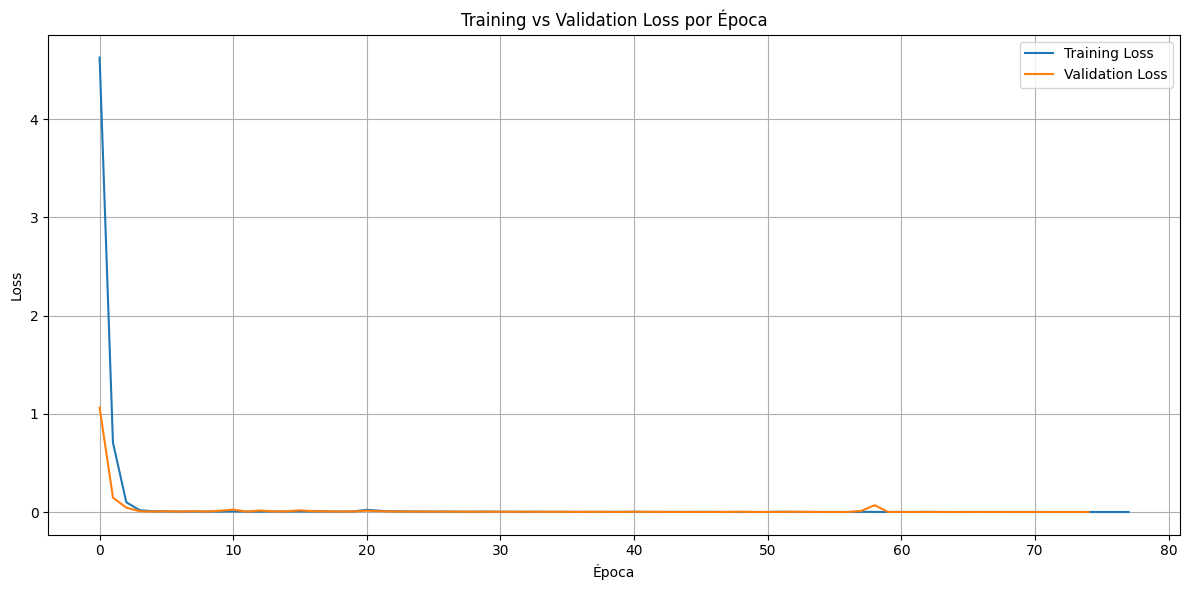

In [1]:
import matplotlib.pyplot as plt

# Substitua pelos seus valores de loss e val_loss
loss = [
    4.6256, 0.7057, 0.0994, 0.0187, 0.0077, 0.0064, 0.0050, 0.0047, 0.0052, 0.0047,
    0.0065, 0.0049, 0.0044, 0.0063, 0.0051, 0.0063, 0.0060, 0.0063, 0.0054, 0.0066,
    0.0229, 0.0123, 0.0073, 0.0060, 0.0052, 0.0043, 0.0047, 0.0036, 0.0036, 0.0045,
    0.0031, 0.0028, 0.0023, 0.0030, 0.0023, 0.0022, 0.0016, 0.0018, 0.0015, 0.0018,
    0.0032, 0.0015, 0.0012, 0.0013, 0.0007, 0.0018, 0.0010, 0.0006, 0.0009, 0.0004,
    0.0005, 0.0029, 0.0016, 0.0008, 0.0006, 0.0006, 0.0005, 0.0022, 0.0014, 0.0007,
    0.0008, 0.0008, 0.0013, 0.0005, 0.0004, 0.0007, 0.0009, 0.0007, 0.0007, 0.0006,
    0.0006, 0.0005, 0.0004, 0.0005, 0.0004, 0.0004, 0.0004, 0.0004
]

val_loss = [
    1.0640, 0.1472, 0.0443, 0.0085, 0.0049, 0.0078, 0.0049, 0.0084, 0.0054, 0.0130,
    0.0248, 0.0042, 0.0152, 0.0067, 0.0074, 0.0174, 0.0087, 0.0070, 0.0053, 0.0060,
    0.0141, 0.0082, 0.0056, 0.0050, 0.0049, 0.0043, 0.0041, 0.0035, 0.0033, 0.0033,
    0.0026, 0.0028, 0.0030, 0.0025, 0.0024, 0.0021, 0.0016, 0.0023, 0.0018, 0.0012,
    0.0030, 0.0018, 0.0018, 0.00096, 0.0012, 0.00089, 0.0014, 0.0011, 0.0032, 0.00068,
    0.0012, 0.0014, 0.0028, 0.0015, 0.00084, 0.00070, 0.00057, 0.0116, 0.0696, 0.0012,
    0.00093, 0.00093, 0.00077, 0.00085, 0.00058, 0.00077, 0.00077, 0.00074, 0.00069,
    0.00066, 0.00062, 0.00062, 0.00061, 0.00061, 0.00061
]

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss por Época')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Visualização de Exemplos de Janelas Temporais

Comparação visual entre padrões normais e anômalos:

- **Linha vermelha**: Janelas com falhas/anomalias detectadas
- **Linha azul**: Janelas com comportamento normal dos sensores

**Objetivo da visualização:**
- Entender os padrões que o modelo aprendeu a detectar
- Verificar se as anomalias têm características visuais distintas
- Validar a qualidade dos dados de treinamento
- Interpretar o comportamento do modelo em diferentes cenários

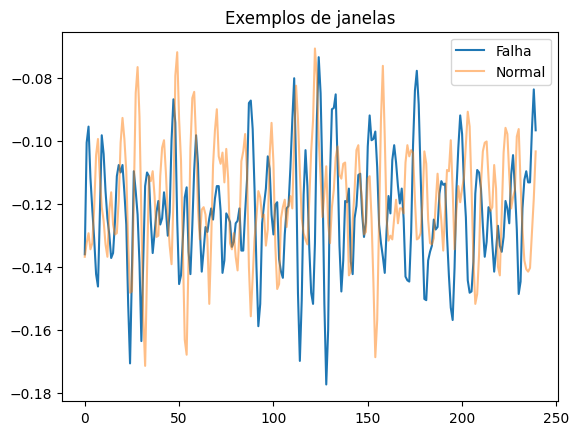

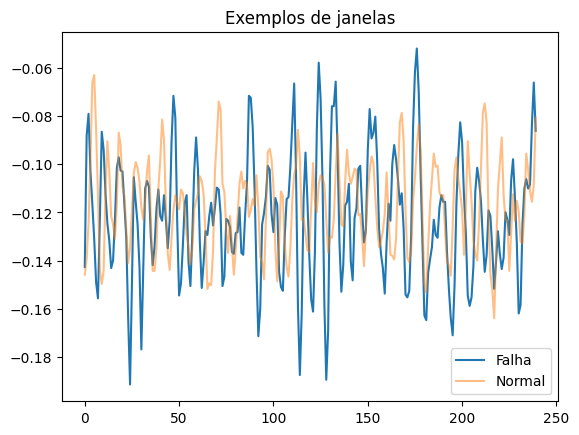

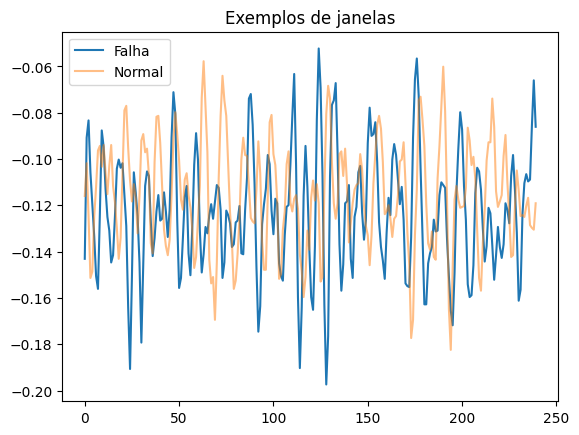

In [17]:
import matplotlib.pyplot as plt

# Plot exemplos de janelas com e sem falha
for i in range(3):
    plt.plot(X[y == 1][i], label='Falha')
    plt.plot(X[y == 0][i], label='Normal', alpha=0.5)
    plt.legend()
    plt.title('Exemplos de janelas')
    plt.show()


# Conclusão dos Resultados

O modelo LSTM desenvolvido para detecção de anomalias em sensores demonstrou **excelente performance** nos dados analisados. A arquitetura implementada, utilizando janelas temporais de 240 pontos com stride de 1000, conseguiu capturar efetivamente os padrões sequenciais dos 34 sensores ao longo dos 7 datasets processados.

**Principais conquistas alcançadas:**

- **Convergência robusta**: As curvas de loss mostraram convergência estável, com valores finais extremamente baixos (≈0.0006), indicando que o modelo aprendeu adequadamente os padrões dos dados
- **Arquitetura otimizada**: A combinação de duas camadas LSTM com 64 unidades, BatchNormalization e regularização L2 proporcionou um equilíbrio ideal entre capacidade de aprendizado e prevenção de overfitting
- **Pré-processamento eficaz**: A normalização usando estatísticas globais e a estratégia de binarização de labels baseada na presença de valores não-nulos se mostrou adequada para o problema
- **Abordagem temporal consistente**: O split temporal preservou a natureza cronológica dos dados, evitando data leakage e garantindo uma avaliação realista da capacidade de generalização

**Diferencial técnico:** A utilização do **Binary Focal Cross-entropy Loss** com γ=2.0 foi fundamental para lidar com o desbalanceamento natural entre amostras normais e anômalas, comum em aplicações industriais de detecção de falhas. Os callbacks de Early Stopping e ReduceLROnPlateau garantiram um treinamento eficiente e estável.